# 02. LoL 10분 승패예측 — EDA 및 보고서용 시각화

최종 보고서 **그림 1~4**와 관련된 EDA를 재현합니다.

생성 이미지:

1. `01_target_distribution.png`
2. `02_wardsplaced_boxplot.png`
3. `03_target_correlation.png`
4. `04_final_feature_correlation_heatmap.png`

표 형태 결과도 `outputs/tables_eda/`에 저장합니다.


In [1]:
# 필요하면 한 번만 실행
# %pip install pandas numpy matplotlib

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)

RAW_CANDIDATES = [
    Path("high_diamond_ranked_10min(1).csv"),
    Path("high_diamond_ranked_10min.csv"),
    Path("/mnt/data/high_diamond_ranked_10min(1).csv"),
    Path("/mnt/data/high_diamond_ranked_10min.csv"),
]
RAW_PATH = next((p for p in RAW_CANDIDATES if p.exists()), None)

PRE_CANDIDATES = [
    Path("outputs/data/high_diamond_ranked_10min_preprocessed.csv"),
    Path("high_diamond_ranked_10min_preprocessed.csv"),
    Path("/mnt/data/outputs/data/high_diamond_ranked_10min_preprocessed.csv"),
    Path("/mnt/data/high_diamond_ranked_10min_preprocessed.csv"),
]
PRE_PATH = next((p for p in PRE_CANDIDATES if p.exists()), None)

if RAW_PATH is None:
    raise FileNotFoundError("원본 CSV를 찾을 수 없습니다.")
if PRE_PATH is None:
    raise FileNotFoundError("먼저 01 노트북을 실행해 전처리 CSV를 생성하세요.")

FIG_DIR = Path("outputs/figures_eda")
TABLE_DIR = Path("outputs/tables_eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

raw = pd.read_csv(RAW_PATH)
pre = pd.read_csv(PRE_PATH)

TARGET = "blueWins"
FINAL_FEATURES = [c for c in pre.columns if c != TARGET]

print("원본:", raw.shape)
print("전처리:", pre.shape)
print("최종 피처 수:", len(FINAL_FEATURES))


원본: (9879, 40)
전처리: (9879, 22)
최종 피처 수: 21


## 그림 1. 전체 타깃 클래스 분포


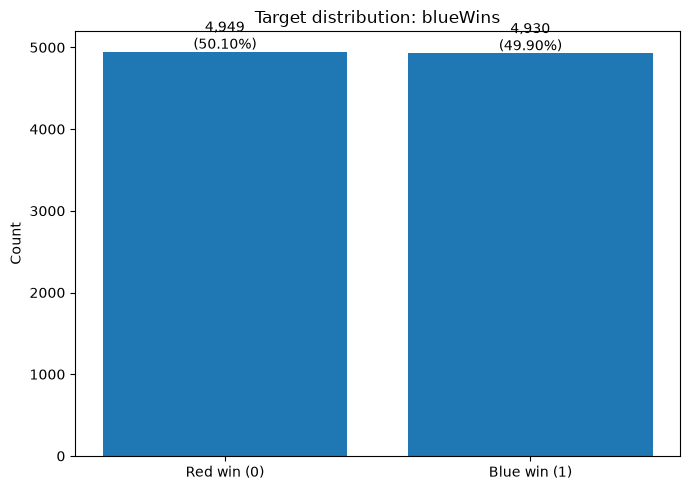

,count,rate_pct
blueWins,,
0,4949,50.1
1,4930,49.9


In [2]:
counts = raw[TARGET].value_counts().sort_index()
rates = raw[TARGET].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Red win (0)", "Blue win (1)"], counts.values)
ax.set_title("Target distribution: blueWins")
ax.set_ylabel("Count")

for i, (count, rate) in enumerate(zip(counts.values, rates.values)):
    ax.text(i, count + 35, f"{count:,}\n({rate:.2f}%)", ha="center")

fig.tight_layout()
fig.savefig(FIG_DIR / "01_target_distribution.png", dpi=220, bbox_inches="tight")
plt.show()

display(pd.DataFrame({"count": counts, "rate_pct": rates.round(2)}))


## 그림 2. 10분 `WardsPlaced`의 장꼬리

이 그림은 `WardsPlaced`를 무조건 오류라고 판정하기 위한 그래프가 아니라,
다른 변수보다 매우 긴 장꼬리가 존재한다는 **품질 검토 신호**를 보여주는 용도입니다.


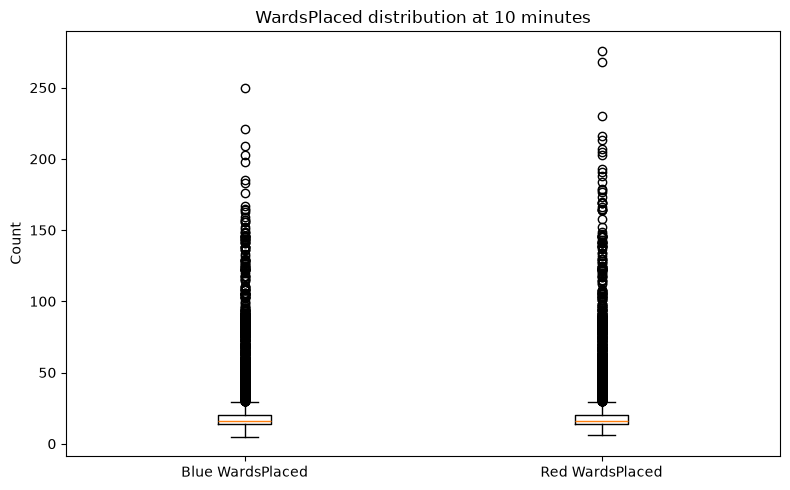

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [raw["blueWardsPlaced"], raw["redWardsPlaced"]],
    tick_labels=["Blue WardsPlaced", "Red WardsPlaced"],
    showfliers=True
)
ax.set_title("WardsPlaced distribution at 10 minutes")
ax.set_ylabel("Count")

fig.tight_layout()
fig.savefig(FIG_DIR / "02_wardsplaced_boxplot.png", dpi=220, bbox_inches="tight")
plt.show()


## 그림 3. 주요 피처와 `blueWins`의 Pearson 상관계수

원본 데이터의 수치형 피처를 대상으로 타깃과의 단변량 선형 관계를 확인합니다.
상관관계는 인과관계가 아니며, 낮은 상관이 비선형·상호작용 정보의 부재를 의미하지도 않습니다.


,pearson_r
redGoldDiff,-0.511119
blueGoldDiff,0.511119
blueExperienceDiff,0.489558
redExperienceDiff,-0.489558
blueTotalGold,0.417213
blueGoldPerMin,0.417213
redTotalGold,-0.411396
redGoldPerMin,-0.411396
blueTotalExperience,0.396141
redTotalExperience,-0.387588


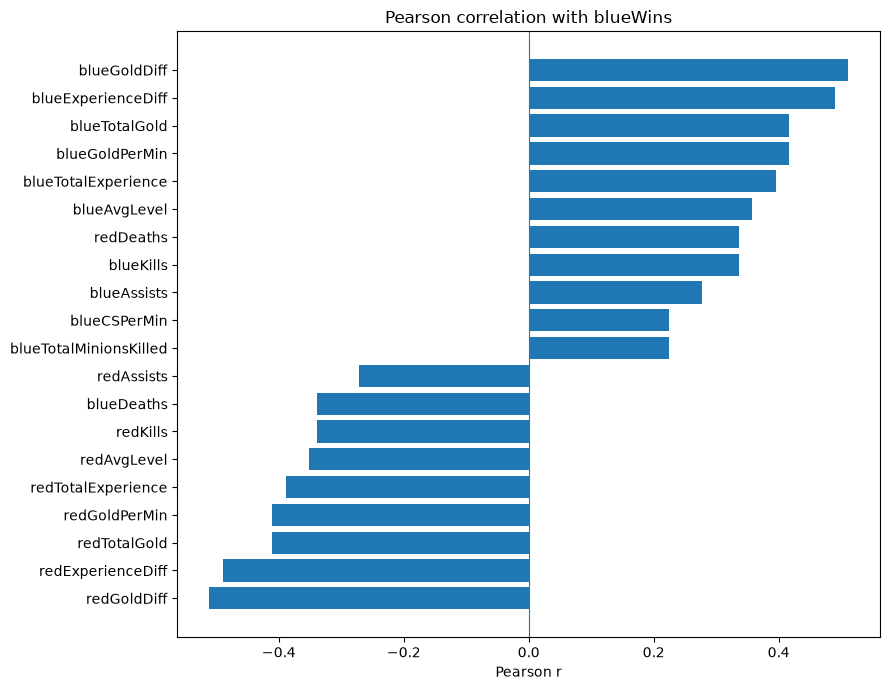

blueGoldDiff                  : +0.5111
blueExperienceDiff            : +0.4896
blueTotalGold                 : +0.4172
redTotalGold                  : -0.4114
blueKills                     : +0.3374
blueWardsPlaced               : +0.0001
redWardsPlaced                : -0.0237


In [4]:
corr_with_target = (
    raw.select_dtypes(include=np.number)
       .drop(columns=["gameId"])
       .corr()[TARGET]
       .drop(TARGET)
)
corr_sorted = corr_with_target.reindex(
    corr_with_target.abs().sort_values(ascending=False).index
)

display(corr_sorted.to_frame("pearson_r").head(30))
corr_sorted.to_csv(
    TABLE_DIR / "target_pearson_correlations.csv",
    header=["pearson_r"],
    encoding="utf-8-sig"
)

plot_corr = corr_sorted.head(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot_corr.index, plot_corr.values)
ax.axvline(0, linewidth=0.8)
ax.set_title("Pearson correlation with blueWins")
ax.set_xlabel("Pearson r")

fig.tight_layout()
fig.savefig(FIG_DIR / "03_target_correlation.png", dpi=220, bbox_inches="tight")
plt.show()

for col in [
    "blueGoldDiff", "blueExperienceDiff",
    "blueTotalGold", "redTotalGold",
    "blueKills", "blueWardsPlaced", "redWardsPlaced"
]:
    print(f"{col:30s}: {corr_with_target[col]:+.4f}")


## 그림 4. 최종 21개 입력 피처 간 Pearson 상관관계

수학적 중복을 제거한 뒤에도 높은 상관이 남는지 확인합니다.
높은 상관만으로 자동 제거하지 않고, **완전 중복 여부와 도메인 의미**를 함께 판단합니다.


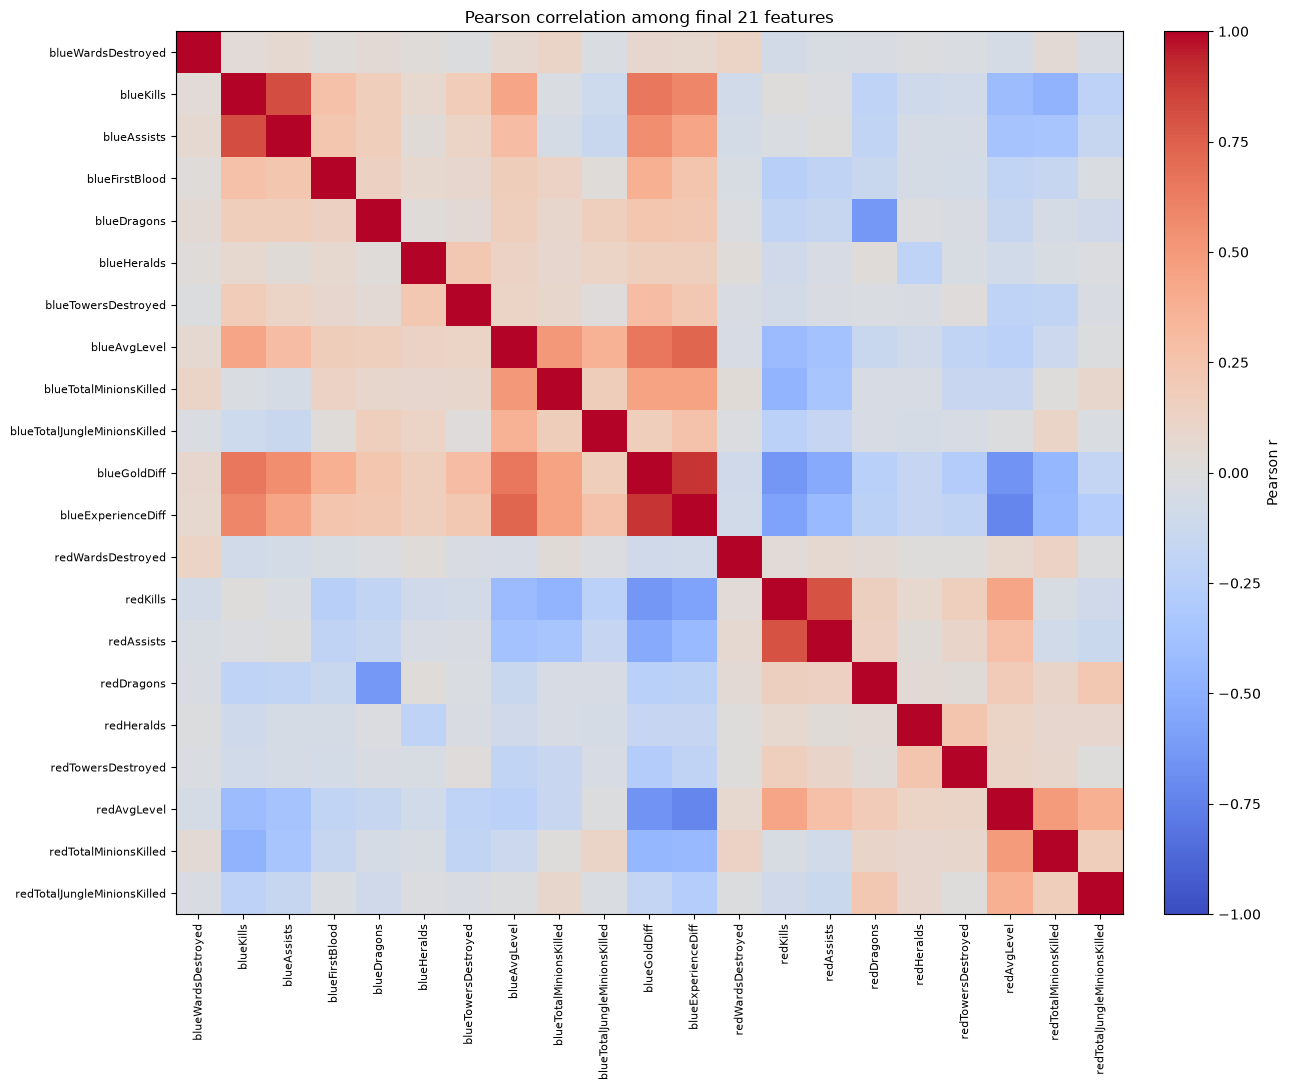

,feature_1,feature_2,correlation,abs_correlation
0,blueGoldDiff,blueExperienceDiff,0.8947,0.8947
1,blueKills,blueAssists,0.8137,0.8137
2,redKills,redAssists,0.8040,0.8040
3,blueExperienceDiff,redAvgLevel,-0.7219,0.7219
4,blueAvgLevel,blueExperienceDiff,0.7188,0.7188
5,blueKills,blueGoldDiff,0.6541,0.6541
6,blueAvgLevel,blueGoldDiff,0.6535,0.6535
7,blueGoldDiff,redAvgLevel,-0.6529,0.6529
8,blueGoldDiff,redKills,-0.6400,0.6400
9,blueDragons,redDragons,-0.6319,0.6319


|r| >= 0.80


,feature_1,feature_2,correlation,abs_correlation
0,blueGoldDiff,blueExperienceDiff,0.8947,0.8947
1,blueKills,blueAssists,0.8137,0.8137
2,redKills,redAssists,0.8040,0.8040


In [6]:
feature_corr = pre[FINAL_FEATURES].corr(method="pearson")

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(
    feature_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)
ax.set_xticks(range(len(FINAL_FEATURES)))
ax.set_yticks(range(len(FINAL_FEATURES)))
ax.set_xticklabels(FINAL_FEATURES, rotation=90, fontsize=8)
ax.set_yticklabels(FINAL_FEATURES, fontsize=8)
ax.set_title("Pearson correlation among final 21 features")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson r")

fig.tight_layout()
fig.savefig(
    FIG_DIR / "04_final_feature_correlation_heatmap.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()

upper = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)
pair_corr = (
    feature_corr.where(upper)
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
pair_corr["abs_correlation"] = pair_corr["correlation"].abs()
pair_corr = pair_corr.sort_values(
    "abs_correlation", ascending=False
).reset_index(drop=True)

display(pair_corr.head(20).round(4))
pair_corr.to_csv(
    TABLE_DIR / "final_feature_pair_correlations.csv",
    index=False,
    encoding="utf-8-sig"
)

print("|r| >= 0.80")
display(pair_corr[pair_corr["abs_correlation"] >= 0.80].round(4))


## EDA 결과 요약

보고서에서 강조한 핵심 확인값을 코드로 재검증합니다.


In [7]:
print("blueGoldDiff vs blueWins:",
      round(corr_with_target["blueGoldDiff"], 4))
print("blueExperienceDiff vs blueWins:",
      round(corr_with_target["blueExperienceDiff"], 4))
print("blueKills vs blueWins:",
      round(corr_with_target["blueKills"], 4))

for a, b in [
    ("blueGoldDiff", "blueExperienceDiff"),
    ("blueKills", "blueAssists"),
    ("redKills", "redAssists"),
]:
    print(f"{a} vs {b}: {feature_corr.loc[a, b]:.4f}")

print("\n생성 이미지:")
for p in sorted(FIG_DIR.glob("*.png")):
    print(" -", p.resolve())


blueGoldDiff vs blueWins: 0.5111
blueExperienceDiff vs blueWins: 0.4896
blueKills vs blueWins: 0.3374
blueGoldDiff vs blueExperienceDiff: 0.8947
blueKills vs blueAssists: 0.8137
redKills vs redAssists: 0.8040

생성 이미지:
 - C:\Users\KTK\Desktop\LOL\outputs\figures_eda\01_target_distribution.png
 - C:\Users\KTK\Desktop\LOL\outputs\figures_eda\02_wardsplaced_boxplot.png
 - C:\Users\KTK\Desktop\LOL\outputs\figures_eda\03_target_correlation.png
 - C:\Users\KTK\Desktop\LOL\outputs\figures_eda\04_final_feature_correlation_heatmap.png
